# Session 01 - Introduction to Deep Learning
### BrainerX AI Masterclass - Ahmed

---

**In this notebook, we will learn:**

1. Essential libraries (NumPy, Matplotlib, PyTorch)
2. Tensors - the fundamental building block of Deep Learning
3. Building the first neuron manually from scratch
4. First Neural Network with PyTorch
5. Full Training Loop (Forward → Loss → Backward → Update)
6. Visualizing training results
7. Practical exercise

---
> **Tip:** Run each cell with `Shift + Enter` and try to understand every line before moving on.


---
## Part 1 - The Essential Libraries
These are the libraries you will see in every Deep Learning project


In [1]:
# ── Core numerical computing
import numpy as np

# ── Plotting & visualization
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 4)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False

# ── Deep Learning framework (THE most important one)
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# ── Data handling
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility — always set a seed!
torch.manual_seed(42)
np.random.seed(42)

# ── Check versions
print(f'NumPy  version : {np.__version__}')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')

# Auto-select device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device   : {device}')

NumPy  version : 1.26.4
PyTorch version: 2.7.1+cpu
CUDA available : False
Using device   : cpu


---
## Part 2 - Tensors: The DNA of Deep Learning

Everything in Deep Learning is a **Tensor** - images, text, weights, gradients.

| Shape | Name |
|-------|------|
| `()` | Scalar (single number) |
| `(n,)` | Vector (1D) |
| `(n, m)` | Matrix (2D) |
| `(n, m, k)` | 3D Tensor (e.g. an RGB image) |
| `(batch, C, H, W)` | 4D Tensor (batch of images) |


In [2]:
# ── Creating tensors
scalar  = torch.tensor(3.14)
vector  = torch.tensor([1.0, 2.0, 3.0])
matrix  = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
zeros   = torch.zeros(3, 4)
ones    = torch.ones(2, 3)
random  = torch.randn(3, 3)   # Normal distribution N(0,1)

print('scalar :', scalar,       '| shape:', scalar.shape)
print('vector :', vector,       '| shape:', vector.shape)
print('matrix :\n', matrix,     '| shape:', matrix.shape)
print('random :\n', random)

scalar : tensor(3.1400) | shape: torch.Size([])
vector : tensor([1., 2., 3.]) | shape: torch.Size([3])
matrix :
 tensor([[1., 2.],
        [3., 4.]]) | shape: torch.Size([2, 2])
random :
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082, -0.6380,  0.4617]])


In [3]:
# ── Tensor operations — same as NumPy but GPU-compatible
a = torch.tensor([2.0, 4.0, 6.0])
b = torch.tensor([1.0, 2.0, 3.0])

print('a + b     =', a + b)
print('a * b     =', a * b)          # element-wise
print('dot(a,b)  =', torch.dot(a, b)) # dot product
print('mean(a)   =', a.mean())
print('a.sum()   =', a.sum())

# Matrix multiplication (used in EVERY neural network layer)
W = torch.randn(3, 2)   # weight matrix
x = torch.randn(2)      # input vector
z = W @ x               # z = Wx  (matrix × vector)
print('\nW shape:', W.shape)
print('x shape:', x.shape)
print('W @ x   :', z, '| shape:', z.shape)

a + b     = tensor([3., 6., 9.])
a * b     = tensor([ 2.,  8., 18.])
dot(a,b)  = tensor(28.)
mean(a)   = tensor(4.)
a.sum()   = tensor(12.)

W shape: torch.Size([3, 2])
x shape: torch.Size([2])
W @ x   : tensor([ 0.9633,  2.2433, -2.9263]) | shape: torch.Size([3])


In [4]:
# ── Reshaping — very common in DL pipelines
t = torch.arange(12, dtype=torch.float32)
print('Original :', t.shape, '->', t)

t_2d = t.reshape(3, 4)
print('\n3×4 matrix:\n', t_2d)

t_3d = t.reshape(2, 2, 3)
print('\n2×2×3 tensor:\n', t_3d)

# Simulate an image batch: (batch_size=2, channels=3, height=4, width=4)
fake_images = torch.randn(2, 3, 4, 4)
print('\nFake image batch shape:', fake_images.shape)

Original : torch.Size([12]) -> tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

3×4 matrix:
 tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

2×2×3 tensor:
 tensor([[[ 0.,  1.,  2.],
         [ 3.,  4.,  5.]],

        [[ 6.,  7.,  8.],
         [ 9., 10., 11.]]])

Fake image batch shape: torch.Size([2, 3, 4, 4])


---
## Part 3 - Build a Neuron from Scratch

The artificial neuron equation:

$$\text{output} = f\left(\sum_{i} w_i x_i + b\right)$$

We build it **manually** without any library - so you understand what happens inside.


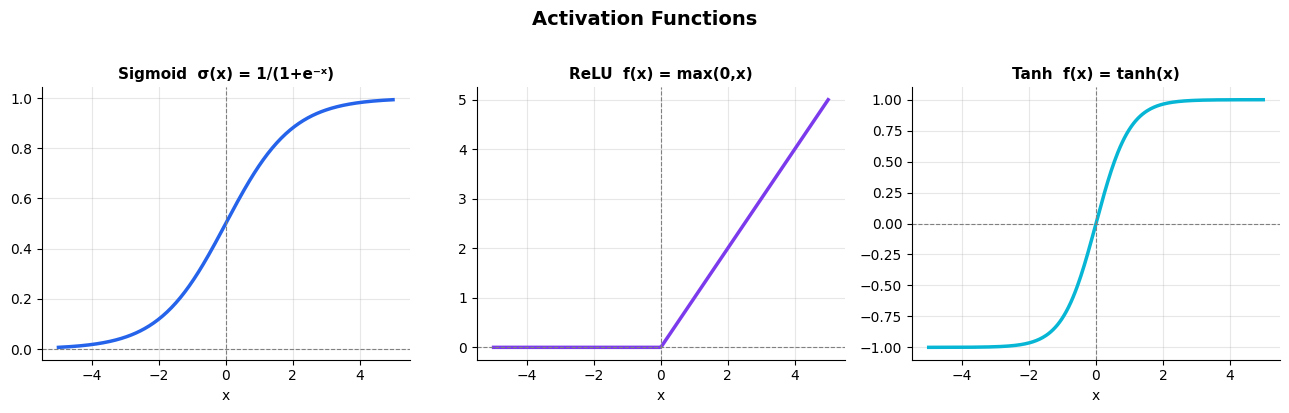

In [5]:
# ── Activation functions — implemented manually
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# ── Plot them side by side
x_range = np.linspace(-5, 5, 300)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#2563EB', '#7C3AED', '#06B6D4']
funcs  = [sigmoid, relu, tanh]
names  = ['Sigmoid  σ(x) = 1/(1+e⁻ˣ)', 'ReLU  f(x) = max(0,x)', 'Tanh  f(x) = tanh(x)']

for ax, fn, name, color in zip(axes, funcs, names, colors):
    ax.plot(x_range, fn(x_range), color=color, linewidth=2.5)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(name, fontsize=11, fontweight='bold')
    ax.set_xlabel('x')
    ax.grid(True, alpha=0.3)

plt.suptitle('Activation Functions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [1]:
# ── A single neuron — fully manual
class Neuron:
    """One artificial neuron: output = activation(w·x + b)"""

    def __init__(self, n_inputs, activation='relu'):
        # Random weight init (small values)
        self.weights = np.random.randn(n_inputs) * 0.1
        self.bias    = 0.0
        self.activation = activation

    def forward(self, x):
        # Step 1: Weighted sum  z = w·x + b
        self.z = np.dot(self.weights, x) + self.bias
        # Step 2: Apply activation
        if self.activation == 'relu':
            self.output = relu(self.z)
        elif self.activation == 'sigmoid':
            self.output = sigmoid(self.z)
        return self.output


# ── Test it
neuron = Neuron(n_inputs=3, activation='relu')

x_input = np.array([0.5, -1.2, 0.8])
output  = neuron.forward(x_input)

print('Weights :', neuron.weights)
print('Bias    :', neuron.bias)
print('Input   :', x_input)
print('z = w·x + b =', neuron.z)
print('Output (ReLU):', output)

NameError: name 'np' is not defined

---
## Part 4 - First Neural Network with PyTorch

We will build a real neural network with PyTorch on a simple classification problem.

**Problem:** Classify 2D points into two categories (Binary Classification)


C:\Users\j\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\j\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128995 (\N{LARGE PURPLE CIRCLE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


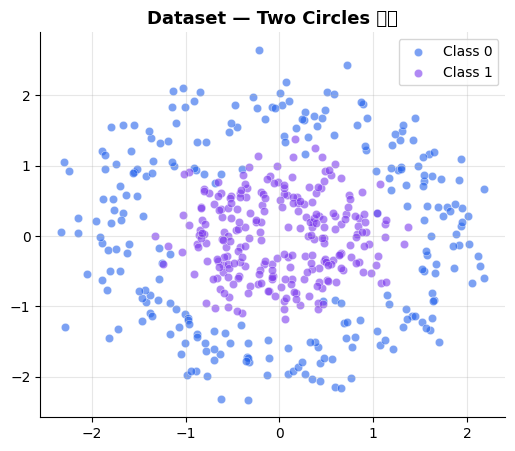

X shape: (500, 2)  |  y shape: (500,)


In [7]:
# ── Generate a simple 2D classification dataset (two moons / circles)
from sklearn.datasets import make_circles
from sklearn.preprocessing import StandardScaler

X_np, y_np = make_circles(n_samples=500, noise=0.15, factor=0.4, random_state=42)
X_np = StandardScaler().fit_transform(X_np)

# Visualize
plt.figure(figsize=(6, 5))
plt.scatter(X_np[y_np==0, 0], X_np[y_np==0, 1], c='#2563EB', alpha=0.6, label='Class 0', edgecolors='white', linewidths=0.4)
plt.scatter(X_np[y_np==1, 0], X_np[y_np==1, 1], c='#7C3AED', alpha=0.6, label='Class 1', edgecolors='white', linewidths=0.4)
plt.title('Dataset — Two Circles 🔵🟣', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f'X shape: {X_np.shape}  |  y shape: {y_np.shape}')

In [8]:
# ── Convert to PyTorch tensors & split train/test
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(y_np, dtype=torch.float32).unsqueeze(1)  # shape (N,1)

# 80/20 split
split     = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# DataLoader — for mini-batch training
train_ds     = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: torch.Size([400, 2])  |  Test: torch.Size([100, 2])


In [9]:
# ── Build the Neural Network
class SimpleNet(nn.Module):
    """
    Input(2) → Hidden(16) → Hidden(16) → Output(1)
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 16),    # Input layer  : 2 features → 16 neurons
            nn.ReLU(),           # Activation
            nn.Linear(16, 16),   # Hidden layer : 16 → 16
            nn.ReLU(),
            nn.Linear(16, 1),    # Output layer : 16 → 1 (binary)
            nn.Sigmoid()         # σ → probability [0,1]
        )

    def forward(self, x):
        return self.net(x)


model = SimpleNet().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

SimpleNet(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 337


---
## Part 5 - The Full Training Loop

This loop is the **heart** of every Deep Learning project:

```
for each epoch:
    for each batch:
        1. Forward pass   -> y_hat = model(x)
        2. Compute loss   -> L = loss(y_hat, y)
        3. Backward pass  -> gradients via backprop
        4. Update weights -> optimizer.step()
```


In [10]:
# ── Loss function & Optimizer
criterion = nn.BCELoss()                         # Binary Cross-Entropy
optimizer = optim.Adam(model.parameters(), lr=0.01)  # Adam optimizer

# ── Training
N_EPOCHS   = 100
train_losses = []
test_accs    = []

for epoch in range(N_EPOCHS):

    # ----- Training phase -----
    model.train()           # puts model in training mode (enables Dropout etc.)
    epoch_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # 1. Forward pass
        y_pred = model(X_batch)

        # 2. Compute loss
        loss = criterion(y_pred, y_batch)

        # 3. Zero gradients → Backward → Update
        optimizer.zero_grad()   # clear old gradients!
        loss.backward()         # backpropagation
        optimizer.step()        # update weights

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ----- Evaluation phase -----
    model.eval()            # disables Dropout, BatchNorm in eval mode
    with torch.no_grad():   # no gradient computation needed
        preds = model(X_test.to(device))
        predicted = (preds > 0.5).float()
        acc = (predicted == y_test.to(device)).float().mean().item()
        test_accs.append(acc)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1:3d}/{N_EPOCHS}] | Loss: {avg_loss:.4f} | Test Acc: {acc*100:.1f}%')

print('\n✅ Training complete!')

Epoch [ 20/100] | Loss: 0.0641 | Test Acc: 93.0%
Epoch [ 40/100] | Loss: 0.0652 | Test Acc: 92.0%
Epoch [ 60/100] | Loss: 0.0755 | Test Acc: 94.0%
Epoch [ 80/100] | Loss: 0.0561 | Test Acc: 93.0%
Epoch [100/100] | Loss: 0.0567 | Test Acc: 93.0%

✅ Training complete!


C:\Users\j\AppData\Local\Temp\ipykernel_25932\3053288166.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\j\AppData\Local\Temp\ipykernel_25932\3053288166.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  plt.tight_layout()
C:\Users\j\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\j\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


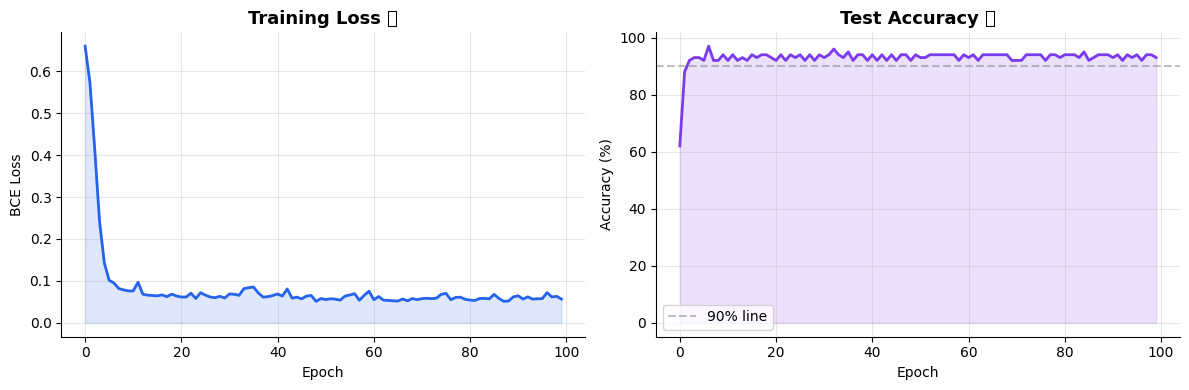

Final Test Accuracy: 93.00%


In [11]:
# ── Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(train_losses, color='#2563EB', linewidth=2)
ax1.fill_between(range(len(train_losses)), train_losses, alpha=0.15, color='#2563EB')
ax1.set_title('Training Loss 📉', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCE Loss')
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot([a*100 for a in test_accs], color='#7C3AED', linewidth=2)
ax2.fill_between(range(len(test_accs)), [a*100 for a in test_accs], alpha=0.15, color='#7C3AED')
ax2.set_title('Test Accuracy 📈', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.axhline(90, color='gray', linestyle='--', alpha=0.5, label='90% line')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Final Test Accuracy: {test_accs[-1]*100:.2f}%')

C:\Users\j\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


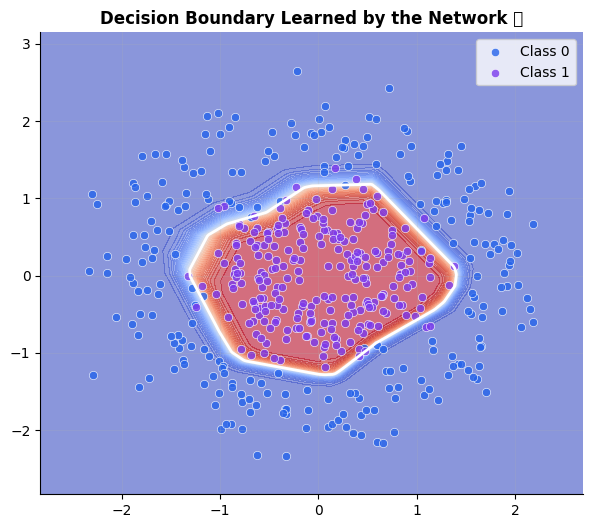

In [12]:
# ── Visualize the Decision Boundary
def plot_decision_boundary(model, X, y):
    model.eval()
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

    with torch.no_grad():
        Z = model(grid.to(device)).cpu().numpy().reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, levels=50, cmap='coolwarm', alpha=0.6)
    plt.contour(xx, yy, Z, levels=[0.5], colors='white', linewidths=2)
    plt.scatter(X[y==0, 0], X[y==0, 1], c='#2563EB', alpha=0.8,
                label='Class 0', edgecolors='white', linewidths=0.5)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='#7C3AED', alpha=0.8,
                label='Class 1', edgecolors='white', linewidths=0.5)
    plt.title('Decision Boundary Learned by the Network 🎯', fontsize=12, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.2)
    plt.show()

plot_decision_boundary(model, X_np, y_np)

---
## Part 6 - Inspecting What's Inside the Model


In [13]:
# ── Look at weights & gradients
print('=== Model Layers & Parameters ===')
for name, param in model.named_parameters():
    print(f'{name:25s} | shape: {str(param.shape):20s} | requires_grad: {param.requires_grad}')

print('\n=== First Layer Weights (sample) ===')
first_layer_weights = list(model.parameters())[0]
print(first_layer_weights.data[:3])   # first 3 rows

print('\n=== Gradient of First Layer (after last backprop) ===')
print(first_layer_weights.grad[:3] if first_layer_weights.grad is not None else 'No gradient yet — run backward first')

=== Model Layers & Parameters ===
net.0.weight              | shape: torch.Size([16, 2])  | requires_grad: True
net.0.bias                | shape: torch.Size([16])     | requires_grad: True
net.2.weight              | shape: torch.Size([16, 16]) | requires_grad: True
net.2.bias                | shape: torch.Size([16])     | requires_grad: True
net.4.weight              | shape: torch.Size([1, 16])  | requires_grad: True
net.4.bias                | shape: torch.Size([1])      | requires_grad: True

=== First Layer Weights (sample) ===
tensor([[-1.1472,  0.6952],
        [-0.7394, -0.3783],
        [-0.7801, -0.8616]])

=== Gradient of First Layer (after last backprop) ===
tensor([[-0.0603,  0.0630],
        [-0.0144,  0.0052],
        [-0.0135,  0.0058]])


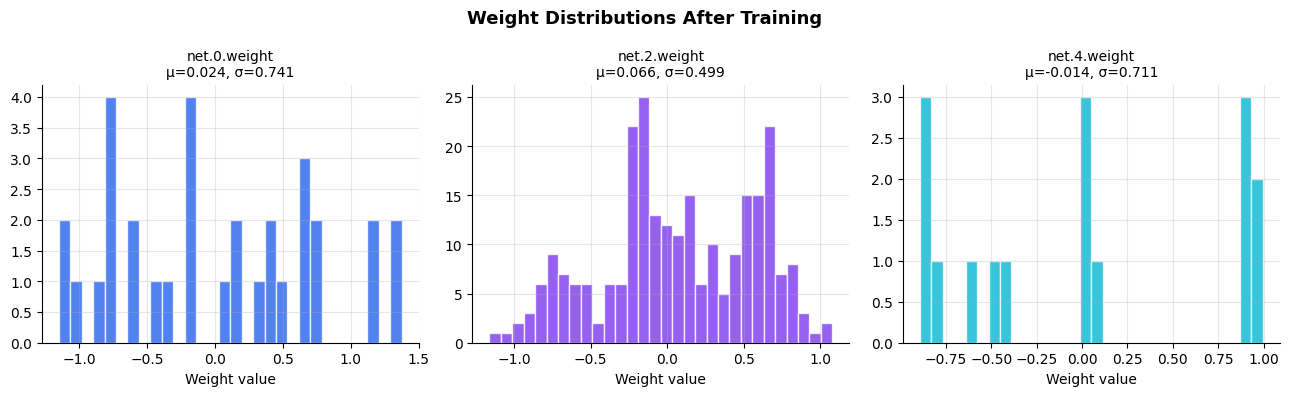

In [14]:
# ── Visualize weight distributions across all layers
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['#2563EB', '#7C3AED', '#06B6D4']
linear_layers = [(name, param) for name, param in model.named_parameters() if 'weight' in name]

for ax, (name, param), color in zip(axes, linear_layers, colors):
    weights = param.detach().cpu().numpy().flatten()
    ax.hist(weights, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{name}\nμ={weights.mean():.3f}, σ={weights.std():.3f}', fontsize=10)
    ax.set_xlabel('Weight value')
    ax.grid(True, alpha=0.3)

plt.suptitle('Weight Distributions After Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 7 - Key Techniques Demo
### 7a - Effect of Learning Rate


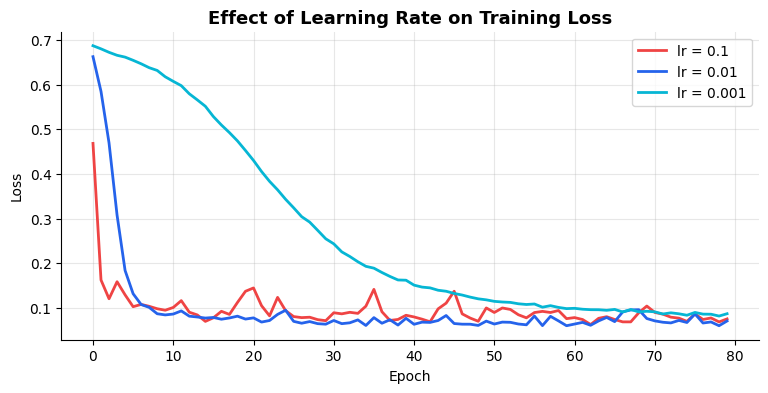

🔴 lr=0.1   → too large: unstable / diverges
🔵 lr=0.01  → just right: fast & stable convergence
🩵 lr=0.001 → too small: slow convergence


In [15]:
# ── Compare 3 learning rates
def train_with_lr(lr, epochs=80):
    torch.manual_seed(42)
    m = SimpleNet().to(device)
    opt = optim.Adam(m.parameters(), lr=lr)
    crit = nn.BCELoss()
    losses = []
    for _ in range(epochs):
        m.train()
        batch_loss = 0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = m(Xb)
            loss = crit(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            batch_loss += loss.item()
        losses.append(batch_loss / len(train_loader))
    return losses

lrs = [0.1, 0.01, 0.001]
colors_lr = ['#EF4444', '#2563EB', '#06B6D4']
results = {lr: train_with_lr(lr) for lr in lrs}

plt.figure(figsize=(9, 4))
for lr, color in zip(lrs, colors_lr):
    plt.plot(results[lr], label=f'lr = {lr}', color=color, linewidth=2)
plt.title('Effect of Learning Rate on Training Loss', fontsize=13, fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

print('🔴 lr=0.1   → too large: unstable / diverges')
print('🔵 lr=0.01  → just right: fast & stable convergence')
print('🩵 lr=0.001 → too small: slow convergence')

### 7b - Dropout: Fighting Overfitting


In [16]:
# ── Net WITH Dropout vs WITHOUT
class NetWithDropout(nn.Module):
    def __init__(self, dropout_rate=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),   # ← Randomly zeros out neurons
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

# Quick train & compare
def quick_eval(model_cls, epochs=60, **kwargs):
    torch.manual_seed(42)
    m = model_cls(**kwargs).to(device)
    opt = optim.Adam(m.parameters(), lr=0.01)
    crit = nn.BCELoss()
    for _ in range(epochs):
        m.train()
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            pred = m(Xb); loss = crit(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        p = m(X_test.to(device))
        acc = ((p > 0.5).float() == y_test.to(device)).float().mean().item()
    return acc

acc_no_drop = quick_eval(NetWithDropout, dropout_rate=0.0)
acc_dropout = quick_eval(NetWithDropout, dropout_rate=0.4)

print(f'Without Dropout → Test Accuracy: {acc_no_drop*100:.1f}%')
print(f'With Dropout    → Test Accuracy: {acc_dropout*100:.1f}%')
print('\n💡 Dropout helps prevent overfitting, especially on small datasets.')

Without Dropout → Test Accuracy: 94.0%
With Dropout    → Test Accuracy: 94.0%

💡 Dropout helps prevent overfitting, especially on small datasets.


---
## Part 8 - Saving and Loading Models


In [17]:
# ── Save the trained model
torch.save(model.state_dict(), 'simple_net.pth')
print('✅ Model saved to simple_net.pth')

# ── Load it back
loaded_model = SimpleNet().to(device)
loaded_model.load_state_dict(torch.load('simple_net.pth', map_location=device))
loaded_model.eval()
print('✅ Model loaded successfully')

# ── Inference on a new example
new_point = torch.tensor([[0.5, 0.3]], dtype=torch.float32).to(device)
with torch.no_grad():
    prob = loaded_model(new_point).item()

print(f'\nNew point {new_point.cpu().numpy()[0]} → Probability of Class 1: {prob:.4f}')
print(f'Predicted class: {int(prob > 0.5)}')

✅ Model saved to simple_net.pth
✅ Model loaded successfully

New point [0.5 0.3] → Probability of Class 1: 0.9999
Predicted class: 1


---
## Part 9 - Your Turn! Exercises

> Try to solve these exercises on your own - solutions exist but don't look at them until you've made an attempt!


### Exercise 1 - Play with Architecture

Modify the network by adding an extra layer or changing the number of neurons and observe how accuracy is affected.

**Try:**
- Two hidden layers instead of one
- Number of neurons: 8, 32, 64
- Replace ReLU with Tanh and observe the difference


In [18]:
# ── Your code here ──
class MyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # TODO: Design your own architecture
            # Try different sizes and activations!
        )

    def forward(self, x):
        return self.net(x)

# Train and evaluate
# my_acc = quick_eval(MyNet)
# print(f'My Net accuracy: {my_acc*100:.1f}%')

### Exercise 2 - Try a Different Optimizer

Switch the optimizer from Adam to:
- `optim.SGD(model.parameters(), lr=0.1, momentum=0.9)`
- `optim.RMSprop(model.parameters(), lr=0.01)`

Compare convergence speed and final accuracy.


In [19]:
# ── Your code here ──
# Hint: replace the optimizer line in the training loop above
# optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)


### Exercise 3 - Multi-Class Classification

Switch the dataset to `make_blobs` or `make_classification` with 3 classes, and adjust:
- The output layer to `nn.Linear(hidden, 3)`
- The final activation to `nn.Softmax(dim=1)`
- The loss to `nn.CrossEntropyLoss()`


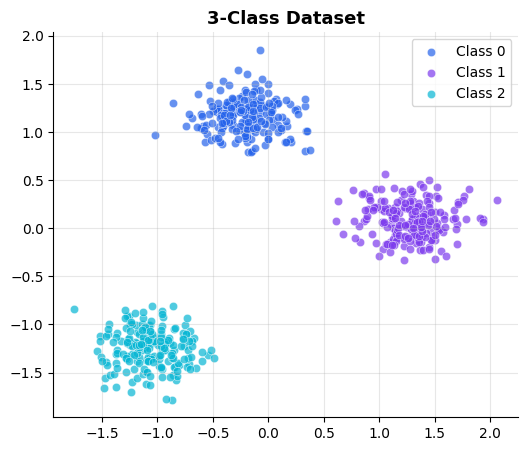

In [20]:
# ── Your code here ──
from sklearn.datasets import make_blobs

X3_np, y3_np = make_blobs(n_samples=600, centers=3, cluster_std=1.2, random_state=42)
X3_np = StandardScaler().fit_transform(X3_np)

# Visualize the dataset
plt.figure(figsize=(6, 5))
for c, color in enumerate(['#2563EB', '#7C3AED', '#06B6D4']):
    mask = y3_np == c
    plt.scatter(X3_np[mask, 0], X3_np[mask, 1], c=color, alpha=0.7,
                label=f'Class {c}', edgecolors='white', linewidths=0.4)
plt.title('3-Class Dataset', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.show()

# TODO: Build a net with 3 outputs and train it!


---
## Summary - What We Covered Today

| Concept | What we did |
|---------|-------------|
| **Libraries** | NumPy, Matplotlib, PyTorch |
| **Tensors** | Create, reshape, operations, matrix multiplication |
| **Neuron** | Manual implementation with activations |
| **Activation Functions** | Sigmoid, ReLU, Tanh - visualized |
| **Neural Network** | `nn.Module`, `nn.Sequential`, `nn.Linear` |
| **Training Loop** | Forward → Loss → `backward()` → `step()` |
| **Evaluation** | Accuracy, decision boundary, weight distributions |
| **Regularization** | Dropout, learning rate tuning |
| **Persistence** | Saving and loading model weights |
